In [6]:
from mlpkan import MLPKAN, FullStateNonlinearityMLPKAN
from SS_KAN_KUL.data_class_SI import SystemIdentificationDataset
from SS_KAN_KUL.model_state_space import StateSpaceKANModel
from SS_KAN_KUL import _utils
import torch
import matplotlib.pyplot as plt

In [7]:
from SS_KAN_KUL.model_state_space import FullStateNonlinearityKAN


device = 'cpu'

dataset = SystemIdentificationDataset(
    test_case="Silverbox",
    test_flag="arrow_extra",
    norm_flag="nothing",
    device=device,
    states_available=False,
    init_matrices_flag='Silverbox',
)

state_dim = dataset.A_init.shape[0]
input_dim = dataset.u_dim
output_dim = dataset.y_dim

# Input KAN
state_kan_input_size = state_dim + input_dim
state_kan_hidden_layers = [] # Hidden layers for state KAN
state_kan_output_size = state_dim

# Output KAN
output_kan_input_size = state_dim + input_dim
output_kan_hidden_layers = [] # Hidden layers for output KAN
output_kan_output_size = output_dim 

state_kan = FullStateNonlinearityMLPKAN(
            state_kan_input_size,
            state_kan_hidden_layers,
            state_kan_output_size, # Use general kan_hidden_layers config
            subnetwork_shape = [12, 12]
)
output_kan = FullStateNonlinearityMLPKAN(
            output_kan_input_size,
            output_kan_hidden_layers, # Use specific hidden layer config
            output_kan_output_size,
            subnetwork_shape = [12, 12]
)

# kan_grid_size = 5
# output_kan_grid_size = 5
# state_kan = FullStateNonlinearityKAN(
#     state_kan_input_size, state_kan_hidden_layers, state_kan_output_size, # Use general kan_hidden_layers config
#     grid_size=kan_grid_size,
#     grid_range=[-1, 1],
#     zero_final_layer=True, # Try initializing final layer to zero for better stability in training
#     # base_activation=torch.nn.Identity,
#     # grid_eps=0.1
# )
# output_kan = FullStateNonlinearityKAN(
#     output_kan_input_size,
#     output_kan_hidden_layers, # Use specific hidden layer config
#     output_kan_output_size,
#     grid_size=output_kan_grid_size, # Use specific grid size config
#     grid_range=[-1,1],
#     zero_final_layer=True, # Try initializing final layer to zero for better stability in training
#     #base_activation=torch.nn.Identity
#     # grid_eps=0.1
# )

output_kan = None
model = StateSpaceKANModel(
    dataset.A_init,
    dataset.B_init,
    dataset.C_init,
    dataset.D_init,
    state_kan,
    output_kan,
    trainable_C=True,
    trainable_D=True,
)
model.to(device)

# load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_99_state_[]_output_[]_batch_128_MLPKAN_subnet[200]_1_ReLU_noOut.pth'
# load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_24_state_[2]_output_[2]_batch_128_MLPKAN.pth'
# load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_54_state_[2]_output_[2]_batch_64_EfficientKAN_grid5_1.pth'
load_model_path = 'SS_KAN_KUL\\test___model_saves_simple_2\\best_model_Silverbox_epoch_94_state_[]_output_[]_batch_64_MLPKAN_subnet[12, 12]_1_nothing.pth'
state_dict = torch.load(load_model_path, map_location=device)
model.load_state_dict(state_dict)

Is C trainable? True
Is D trainable? True


<All keys matched successfully>

In [8]:
# Total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

# Non-trainable (frozen) parameters
non_trainable_params = total_params - trainable_params
print(f"Non-trainable parameters: {non_trainable_params:,}")

Total parameters: 1,173
Trainable parameters: 1,173
Non-trainable parameters: 0


In [9]:
model.eval()

# Access data and parameters from dataset object
u_train_norm = dataset.u_train_norm
y_train_norm = dataset.y_train_norm
u_test_norm = dataset.u_test_norm
y_test_norm = dataset.y_test_norm
y_min = dataset.x_min 
y_max = dataset.x_max
norm_flag = dataset.norm_flag

pred_train_eval_norm = None
pred_test_eval_norm = None
y_train_norm_target_eval = None
y_test_norm_target_eval = None
pred_state_train_norm = None
pred_state_test_norm = None

state_dim = getattr(model, 'state_dim', None)

# --- Simulate Training Data ---
with torch.no_grad():
    print(f"    Simulating full train sequence ({len(u_train_norm)} steps)...")
    current_state_train = torch.zeros(1, state_dim, device=device)
    output_pred_list_train = []
    state_train_norm_list = []
    state_train_norm_list.append(current_state_train.clone()) # Store x(0) guess
    for t in range(len(u_train_norm)):
        current_input = u_train_norm[t].unsqueeze(0)
        next_state_train, output_pred_train = model(current_state_train, current_input)
        output_pred_list_train.append(output_pred_train)
        state_train_norm_list.append(next_state_train.clone()) # Store x(t+1)
        current_state_train = next_state_train
    pred_train_norm = torch.cat(output_pred_list_train, dim=0).cpu().numpy()
    pred_state_train_norm = torch.cat(state_train_norm_list[1:]).cpu().numpy()
    final_state_from_train = current_state_train.detach()
    target_train_norm = y_train_norm.cpu().numpy()

    # --- Simulate Testing Data ---

    print(f"    Simulating full test sequence ({len(u_test_norm)} steps)...")
    current_state_test = final_state_from_train
    output_pred_list_test = []
    state_test_norm_list = []
    state_test_norm_list.append(current_state_test.clone()) # Store initial state x(0) for test
    for t in range(len(u_test_norm)):
        current_input = u_test_norm[t].unsqueeze(0)
        next_state_test, output_pred_test = model(current_state_test, current_input)
        output_pred_list_test.append(output_pred_test)
        current_state_test = next_state_test
        state_test_norm_list.append(next_state_test.clone()) # Store x(t+1)
    pred_test_norm = torch.cat(output_pred_list_test, dim=0).cpu().numpy()
    target_test_norm = y_test_norm.cpu().numpy()
    pred_state_test_norm = torch.cat(state_test_norm_list[1:]).cpu().numpy()


    Simulating full train sequence (65062 steps)...
    Simulating full test sequence (40475 steps)...


C:\Users\Maarten\AppData\Local\Temp\ipykernel_20880\1126223932.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u = torch.tensor(u_train_norm, device=device)


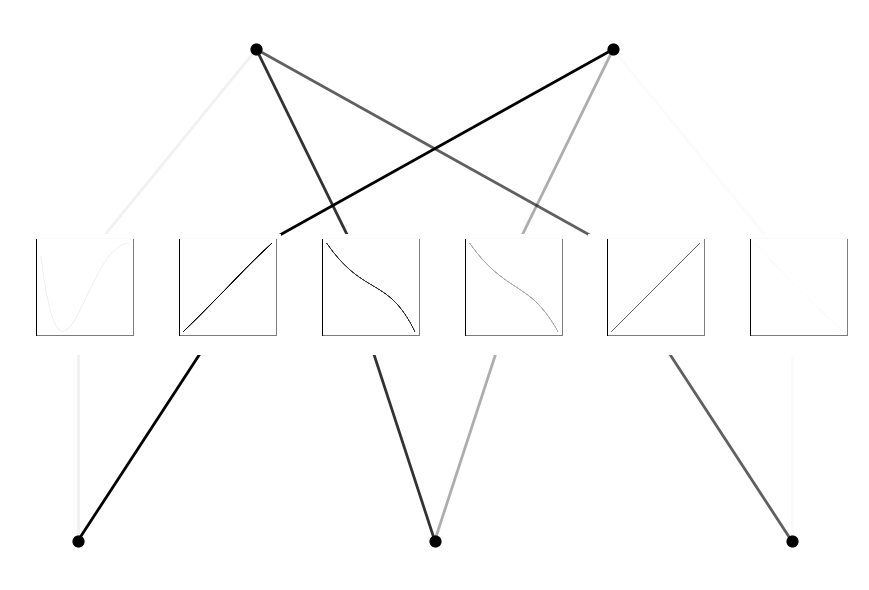

In [10]:

state = torch.tensor(pred_state_train_norm, device=device)
u = torch.tensor(u_train_norm, device=device)
# state = torch.linspace(-1, 1, steps=pred_state_test_norm.shape[0], device=device).unsqueeze(-1).repeat(1, pred_state_test_norm.shape[1])
# u = torch.linspace(-1, 1, steps=u_test_norm.shape[0], device=device).unsqueeze(-1).repeat(1, u_test_norm.shape[1])
if state is not None and u is not None:            
    inp = torch.cat([state, u], dim=-1)
elif state is not None and u is None:             
    inp = state


state_mlpkan_model = model.state_kan_model.kan
state_mlpkan_model(inp, save_activations=True)

state_mlpkan_model.plot(scale=0.5, edge_plot_scale=1.5, attribution_score_alpha=True, tick=False, sample=False)

In [11]:
# pre, post = state_mlpkan_model.get_activation(0,0,0)
# rank = torch.argsort(pre.squeeze())
# pre = pre[rank]
# post = post[rank]
# plt.plot(pre[:].detach().cpu(), post[:].detach().cpu())
# plt.xlabel("input")
# plt.ylabel("output")
# plt.title("subnetwork activation")
# # plt.scatter(pre[:].detach().cpu(), post[:].detach().cpu(), s=8, label='Pre-activations')
# plt.show()

In [12]:
# # Create design matrix [x^3, x^2, x, 1]
# x = pre.squeeze()
# design_matrix = torch.stack([x**3, x**2, x, torch.ones_like(x)], dim=1)

# # Least squares fit
# coeffs = torch.linalg.lstsq(design_matrix, post.squeeze().unsqueeze(-1)).solution.squeeze()
# print("Cubic coefficients:", coeffs)

In [13]:
# plt.plot(x.detach().cpu(), post.squeeze().detach().cpu(), label='Data')
# plt.plot(x.detach().cpu(), (coeffs[0]*x**3 + coeffs[1]*x**2 + coeffs[2]*x + coeffs[3]).detach().cpu(), label='Cubic Fit', linestyle='--')
# plt.xlabel("input")
# plt.ylabel("output")
# plt.title("Cubic Fit to Subnetwork Activation")
# plt.grid(True)
# plt.legend()
# plt.show()

In [14]:
# plt.plot(x.detach().cpu(), post.squeeze().detach().cpu() - (coeffs[2]*x).detach().cpu(), label='Data')
# plt.plot(x.detach().cpu(), (coeffs[0]*x**3 + coeffs[1]*x**2 + coeffs[3]).detach().cpu(), label='Cubic Fit without Linear Term', linestyle='--')
# plt.xlabel("input")
# plt.ylabel("output")
# plt.title("Cubic Fit without Linear Term")
# plt.grid(True)
# plt.legend()
# plt.show()

In [15]:
print(f'A matrix:\n{model.A}')
print(f'B matrix:\n{model.B}')
print(f'C matrix:\n{model.C}')
print(f'D matrix:\n{model.D}')

A matrix:
Parameter containing:
tensor([[ 0.7638, -0.2331],
        [ 0.3073,  0.8417]], requires_grad=True)
B matrix:
Parameter containing:
tensor([[ 0.3431],
        [-0.0550]], requires_grad=True)
C matrix:
Parameter containing:
tensor([[0.6611, 0.3208]], requires_grad=True)
D matrix:
Parameter containing:
tensor([[0.0451]], requires_grad=True)


In [16]:
simulation_results = _utils.simulate_model(model, dataset, device)

# 2. Calculate metrics from the simulation results
evaluation_metrics = _utils.calculate_metrics(simulation_results)

# 3. Print the results
print("\n--- Performance Metrics (Original Scale) ---")
print(f"MAE (Train): {evaluation_metrics['mae_train']:.4f}")
print(f"RMSE (Train): {evaluation_metrics['rmse_train']:.4f}")
print(f"MAE (Test): {evaluation_metrics['mae_test']:.4f}")
print(f"RMSE (Test): {evaluation_metrics['rmse_test']:.4f}")



--- Starting Evaluation ---
  Simulation Mode: States Unavailable (Output Error with State Handoff, No Warmup)
    Simulating full train sequence (65062 steps)...
    Simulating full test sequence (40475 steps)...

--- Performance Metrics (Original Scale) ---
MAE (Train): 0.0005
RMSE (Train): 0.0008
MAE (Test): 0.0007
RMSE (Test): 0.0018


=== State-to-state update decomposition (full KAN, multi-layer compatible) ===

A matrix:
tensor([[ 0.7638, -0.2331],
        [ 0.3073,  0.8417]])


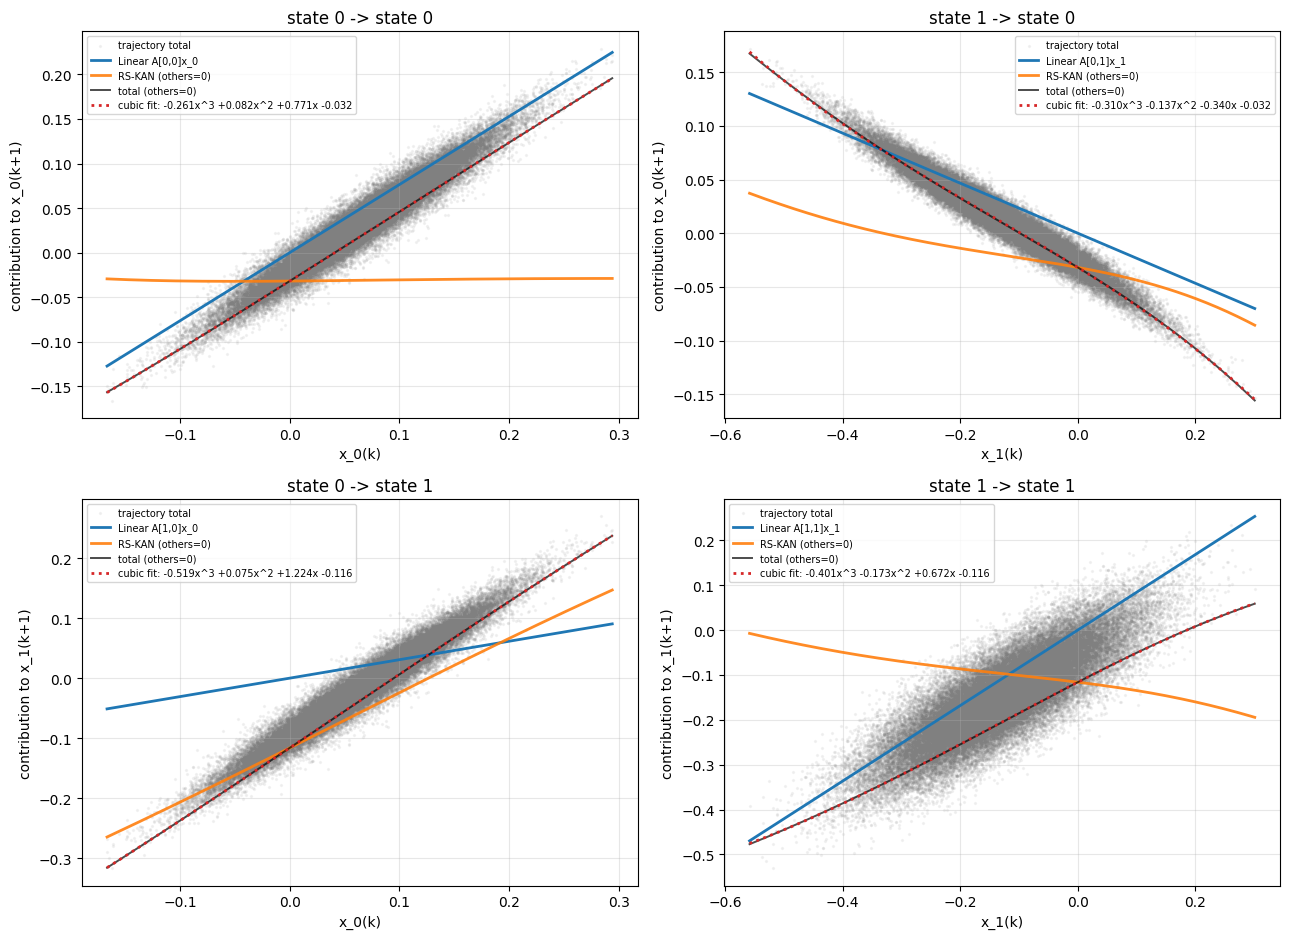


=== Input-to-state update decomposition (full KAN) ===

B matrix:
tensor([[ 0.3431],
        [-0.0550]])


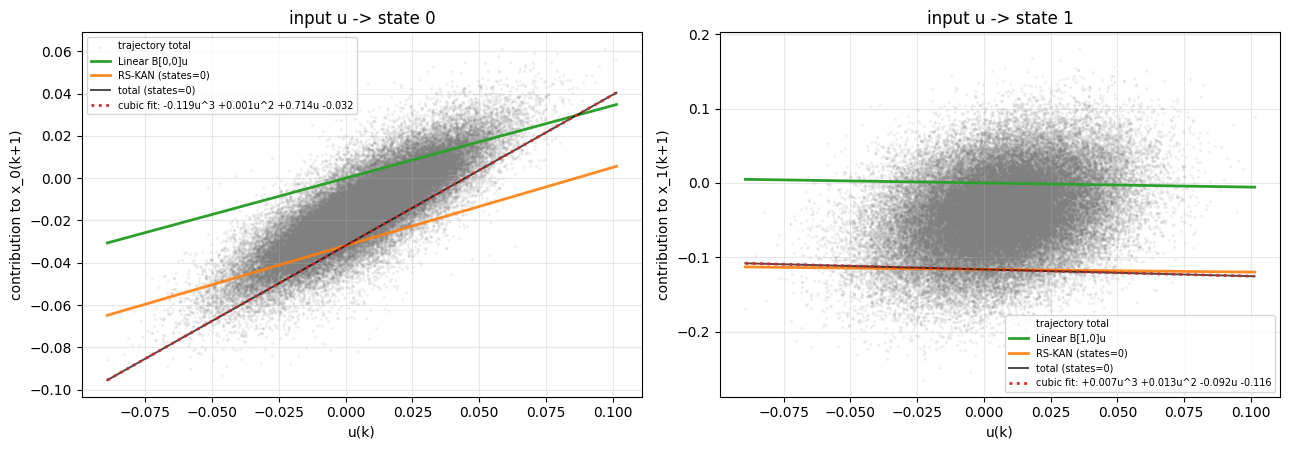


Per-slice RMS magnitudes (state-to-state, grid with others=0):
  i=0 -> j=0: linear_rms=0.11287, nonlinear_rms=0.03061, nonlin/lin=0.271
  i=0 -> j=1: linear_rms=0.04541, nonlinear_rms=0.13366, nonlin/lin=2.943
  i=1 -> j=0: linear_rms=0.06527, nonlinear_rms=0.03683, nonlin/lin=0.564
  i=1 -> j=1: linear_rms=0.23566, nonlinear_rms=0.10851, nonlin/lin=0.460

Per-slice RMS magnitudes (input-to-state, grid with states=0):
  u -> j=0: linear_rms=0.01905, nonlinear_rms=0.03598, nonlin/lin=1.888
  u -> j=1: linear_rms=0.00306, nonlinear_rms=0.11639, nonlin/lin=38.079


In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ----- Setup -----
state = torch.as_tensor(pred_state_train_norm, dtype=torch.float32, device=device)
u     = torch.as_tensor(u_train_norm,         dtype=torch.float32, device=device)
if u.dim() == 1:
    u = u.unsqueeze(-1)

state_dim = model.state_dim
input_dim = u.shape[1]
n_grid    = 400

A = model.A.detach()
B = model.B.detach()

state_ranges = [(state[:, i].min().item(), state[:, i].max().item()) for i in range(state_dim)]
u_range      = (u[:, 0].min().item(), u[:, 0].max().item())

# Full KAN output along the trajectory (depends on all inputs)
with torch.no_grad():
    f_traj = model.state_kan_model(state=state, u=u)  # [N, state_dim]

def kan_slice(varying_idx, varying_vals, is_input):
    """Full KAN output when only one input varies, others held at 0."""
    n = varying_vals.shape[0]
    s   = torch.zeros(n, state_dim, device=device)
    u_g = torch.zeros(n, input_dim, device=device)
    if is_input:
        u_g[:, varying_idx] = varying_vals
    else:
        s[:, varying_idx] = varying_vals
    with torch.no_grad():
        return model.state_kan_model(state=s, u=u_g)

# ============ State-to-state update ============
print('=== State-to-state update decomposition (full KAN, multi-layer compatible) ===')
print(f'\nA matrix:\n{A}')

fig, axes = plt.subplots(state_dim, state_dim, figsize=(13, 10))
if state_dim == 1:
    axes = np.array([[axes]])

for i in range(state_dim):
    xi_grid = torch.linspace(state_ranges[i][0], state_ranges[i][1], n_grid, device=device)
    f_grid  = kan_slice(i, xi_grid, is_input=False)   # [n_grid, state_dim]
    xi_traj = state[:, i]

    for j in range(state_dim):
        ax = axes[j, i] if state_dim > 1 else axes[0, 0]

        # ---- Grid (others = 0) ----
        phi_ij_grid = f_grid[:, j]
        lin_ij_grid = A[j, i] * xi_grid
        total_grid  = lin_ij_grid + phi_ij_grid

        X_cubic = torch.stack([xi_grid**3, xi_grid**2, xi_grid, torch.ones_like(xi_grid)], dim=1)
        coef = torch.linalg.lstsq(X_cubic, total_grid.unsqueeze(-1)).solution.squeeze()
        a3, a2, a1, a0 = [c.item() for c in coef]
        edge_fit = (coef[0]*xi_grid**3 + coef[1]*xi_grid**2 + coef[2]*xi_grid + coef[3])
        fit_label = f'cubic fit: {a3:+.3f}x^3 {a2:+.3f}x^2 {a1:+.3f}x {a0:+.3f}'

        # ---- Trajectory (all inputs vary as in data) ----
        # y = A[j,i] * x_i(k) + f(x(k), u(k))[j]
        # i.e. the linear-from-i part plus the full multivariate KAN output
        phi_traj_full = f_traj[:, j]
        lin_traj      = A[j, i] * xi_traj
        total_traj    = lin_traj + phi_traj_full

        xg = xi_grid.detach().cpu()
        xt = xi_traj.detach().cpu()

        # Scatter underneath, lines on top
        ax.scatter(xt, total_traj.detach().cpu(),
                   s=2, alpha=0.08, color='gray', rasterized=True,
                   label='trajectory total')
        ax.plot(xg, lin_ij_grid.detach().cpu(),  lw=2.0, color='C0', label=f'Linear A[{j},{i}]x_{i}')
        ax.plot(xg, phi_ij_grid.detach().cpu(),  lw=2.0, color='C1', alpha=0.9, label='RS-KAN (others=0)')
        ax.plot(xg, total_grid.detach().cpu(),   '-',  lw=1.4, color='black', alpha=0.7, label='total (others=0)')
        ax.plot(xg, edge_fit.detach().cpu(),     ':',  lw=2.0, color='C3', label=fit_label)

        ax.set_title(f'state {i} -> state {j}')
        ax.set_xlabel(f'x_{i}(k)')
        ax.set_ylabel(f'contribution to x_{j}(k+1)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=7)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("./SS_KAN_KUL/test___model_saves_simple_2/stateupdates.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()


# ============ Input-to-state update ============
print('\n=== Input-to-state update decomposition (full KAN) ===')
print(f'\nB matrix:\n{B}')

if input_dim != 1:
    print(f'Note: input_dim={input_dim}. Plotting first input channel only (u_0).')

fig_u, axes_u = plt.subplots(1, state_dim, figsize=(13, 5))
if state_dim == 1:
    axes_u = [axes_u]

u_grid_vals = torch.linspace(u_range[0], u_range[1], n_grid, device=device)
f_u_grid    = kan_slice(0, u_grid_vals, is_input=True)
u_traj      = u[:, 0]

for j in range(state_dim):
    axu = axes_u[j]

    # Grid (states = 0)
    phi_uj_grid  = f_u_grid[:, j]
    lin_uj_grid  = B[j, 0] * u_grid_vals
    total_uj_grid = lin_uj_grid + phi_uj_grid

    U_cubic = torch.stack([u_grid_vals**3, u_grid_vals**2, u_grid_vals, torch.ones_like(u_grid_vals)], dim=1)
    coef_u = torch.linalg.lstsq(U_cubic, total_uj_grid.unsqueeze(-1)).solution.squeeze()
    b3, b2, b1, b0 = [c.item() for c in coef_u]
    edge_fit_u = (coef_u[0]*u_grid_vals**3 + coef_u[1]*u_grid_vals**2
                  + coef_u[2]*u_grid_vals + coef_u[3])
    fit_u_label = f'cubic fit: {b3:+.3f}u^3 {b2:+.3f}u^2 {b1:+.3f}u {b0:+.3f}'

    # Trajectory
    phi_traj_full = f_traj[:, j]
    lin_uj_traj   = B[j, 0] * u_traj
    total_uj_traj = lin_uj_traj + phi_traj_full

    ug = u_grid_vals.detach().cpu()
    ut = u_traj.detach().cpu()

    axu.scatter(ut, total_uj_traj.detach().cpu(),
                s=2, alpha=0.08, color='gray', rasterized=True,
                label='trajectory total')
    axu.plot(ug, lin_uj_grid.detach().cpu(),   lw=2.0, color='C2', label=f'Linear B[{j},0]u')
    axu.plot(ug, phi_uj_grid.detach().cpu(),   lw=2.0, color='C1', alpha=0.9, label='RS-KAN (states=0)')
    axu.plot(ug, total_uj_grid.detach().cpu(), '-',  lw=1.4, color='black', alpha=0.7, label='total (states=0)')
    axu.plot(ug, edge_fit_u.detach().cpu(),    ':',  lw=2.0, color='C3', label=fit_u_label)

    axu.set_title(f'input u -> state {j}')
    axu.set_xlabel('u(k)')
    axu.set_ylabel(f'contribution to x_{j}(k+1)')
    axu.grid(True, alpha=0.3)
    axu.legend(loc='best', fontsize=7)

fig_u.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("./SS_KAN_KUL/test___model_saves_simple_2/inputupdates.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()


# ============ Diagnostics ============
print('\nPer-slice RMS magnitudes (state-to-state, grid with others=0):')
for i in range(state_dim):
    xi_grid = torch.linspace(state_ranges[i][0], state_ranges[i][1], n_grid, device=device)
    f_grid  = kan_slice(i, xi_grid, is_input=False)
    for j in range(state_dim):
        lin_rms = torch.sqrt(torch.mean((A[j, i] * xi_grid)**2)).item()
        non_rms = torch.sqrt(torch.mean(f_grid[:, j]**2)).item()
        print(f'  i={i} -> j={j}: linear_rms={lin_rms:.5f}, '
              f'nonlinear_rms={non_rms:.5f}, nonlin/lin={non_rms/(lin_rms+1e-12):.3f}')

print('\nPer-slice RMS magnitudes (input-to-state, grid with states=0):')
f_u_grid = kan_slice(0, u_grid_vals, is_input=True)
for j in range(state_dim):
    lin_rms = torch.sqrt(torch.mean((B[j, 0] * u_grid_vals)**2)).item()
    non_rms = torch.sqrt(torch.mean(f_u_grid[:, j]**2)).item()
    print(f'  u -> j={j}: linear_rms={lin_rms:.5f}, '
          f'nonlinear_rms={non_rms:.5f}, nonlin/lin={non_rms/(lin_rms+1e-12):.3f}')

=== State-to-state update decomposition ===
Each subplot shows one edge i -> j in x_{k+1,j}:
linear part A[j,i] * x_i, nonlinear edge phi_{i->j}(x_i), total edge, and cubic fit of total edge.

A matrix:
tensor([[ 0.7638, -0.2331],
        [ 0.3073,  0.8417]])


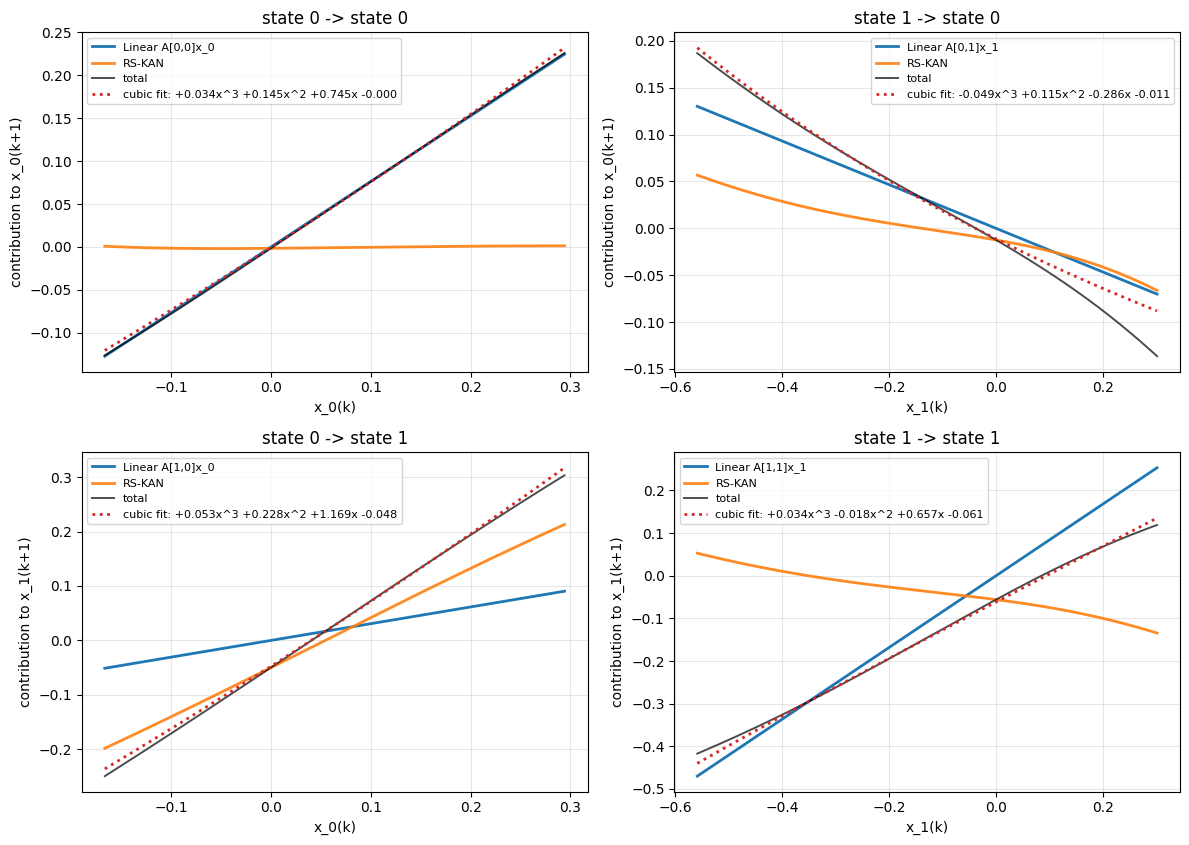


=== Input-to-state update decomposition ===
Two extra plots: u -> state 0 and u -> state 1.
Each uses linear B[j,0] * u, nonlinear input edge, total edge, and cubic fit of total edge.

B matrix:
tensor([[ 0.3431],
        [-0.0550]])


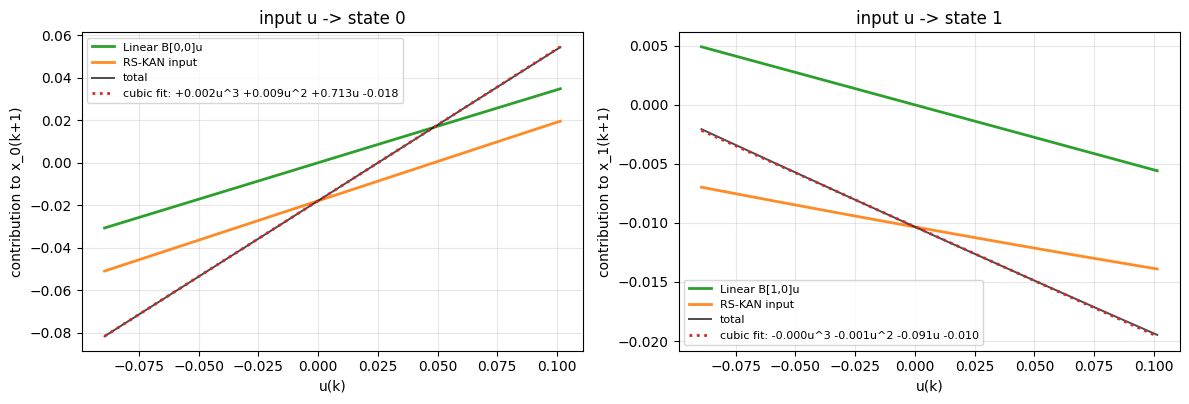


Per-edge RMS magnitudes (state-to-state):
  i=0 -> j=0: linear_rms=0.06548, nonlinear_rms=0.00100, nonlin/lin=0.015
  i=0 -> j=1: linear_rms=0.02635, nonlinear_rms=0.05375, nonlin/lin=2.040
  i=1 -> j=0: linear_rms=0.03910, nonlinear_rms=0.01054, nonlin/lin=0.270
  i=1 -> j=1: linear_rms=0.14116, nonlinear_rms=0.04054, nonlin/lin=0.287

Per-edge RMS magnitudes (input-to-state):
  u -> j=0: linear_rms=0.00791, nonlinear_rms=0.01766, nonlin/lin=2.233
  u -> j=1: linear_rms=0.00127, nonlinear_rms=0.01059, nonlin/lin=8.345


In [18]:
import torch
import matplotlib.pyplot as plt

# Build inputs and store MLPKAN edge activations
state = torch.as_tensor(pred_state_train_norm, dtype=torch.float32, device=device)
u = torch.as_tensor(u_train_norm, dtype=torch.float32, device=device)
inp = torch.cat([state, u], dim=-1)

state_mlpkan_model = model.state_kan_model.kan
_ = state_mlpkan_model(inp, save_activations=True)

state_dim = model.state_dim
input_dim = u.shape[1]
A = model.A.detach()
B = model.B.detach()

print('=== State-to-state update decomposition ===')
print('Each subplot shows one edge i -> j in x_{k+1,j}:')
print('linear part A[j,i] * x_i, nonlinear edge phi_{i->j}(x_i), total edge, and cubic fit of total edge.')
print(f'\nA matrix:\n{A}')

# 2x2 plot for state-to-state edges
fig, axes = plt.subplots(state_dim, state_dim, figsize=(12, 9), sharex=False, sharey=False)
if state_dim == 1:
    axes = [[axes]]

for i in range(state_dim):
    for j in range(state_dim):
        ax = axes[j][i] if state_dim > 1 else axes[0][0]

        pre, post = state_mlpkan_model.get_activation(0, i, j)
        rank = torch.argsort(pre.squeeze())

        x_i = pre.squeeze()[rank]
        phi_ij = post.squeeze()[rank]
        lin_ij = A[j, i] * x_i
        edge_sum_ij = lin_ij + phi_ij

        # Best cubic fit for total edge
        X_cubic = torch.stack([x_i**3, x_i**2, x_i, torch.ones_like(x_i)], dim=1)
        coef = torch.linalg.lstsq(X_cubic, edge_sum_ij.unsqueeze(-1)).solution.squeeze()
        a3, a2, a1, a0 = [c.item() for c in coef]
        edge_fit = coef[0] * x_i**3 + coef[1] * x_i**2 + coef[2] * x_i + coef[3]
        fit_label = f'cubic fit: {a3:+.3f}x^3 {a2:+.3f}x^2 {a1:+.3f}x {a0:+.3f}'

        ax.plot(x_i.detach().cpu(), lin_ij.detach().cpu(), lw=2.0, color='C0', label=f'Linear A[{j},{i}]x_{i}')
        ax.plot(x_i.detach().cpu(), phi_ij.detach().cpu(), lw=2.0, color='C1', alpha=0.9, label='RS-KAN')
        ax.plot(x_i.detach().cpu(), edge_sum_ij.detach().cpu(), '-', lw=1.4, color='black', alpha=0.7, label='total')
        ax.plot(x_i.detach().cpu(), edge_fit.detach().cpu(), ':', lw=2.0, color='C3', label=fit_label)

        ax.set_title(f'state {i} -> state {j}')
        ax.set_xlabel(f'x_{i}(k)')
        ax.set_ylabel(f'contribution to x_{j}(k+1)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)

# fig.suptitle('State update: linear A term + RS-KAN state term', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("./SS_KAN_KUL/test___model_saves_simple_2/stateupdates.pdf", bbox_inches="tight", facecolor="white")
plt.show()

print('\n=== Input-to-state update decomposition ===')
print('Two extra plots: u -> state 0 and u -> state 1.')
print('Each uses linear B[j,0] * u, nonlinear input edge, total edge, and cubic fit of total edge.')
print(f'\nB matrix:\n{B}')

# 1x2 plots for input u -> each state (assuming one input channel)
if input_dim != 1:
    print(f'Note: input_dim={input_dim}. Plotting first input channel only (u_0).')

u_idx = state_dim  # In FullStateNonlinearityMLPKAN input is [state..., u...]
fig_u, axes_u = plt.subplots(1, state_dim, figsize=(12, 4.5), sharex=False, sharey=False)
if state_dim == 1:
    axes_u = [axes_u]

for j in range(state_dim):
    axu = axes_u[j]

    pre_u, post_u = state_mlpkan_model.get_activation(0, u_idx, j)
    rank_u = torch.argsort(pre_u.squeeze())

    u_vals = pre_u.squeeze()[rank_u]
    phi_uj = post_u.squeeze()[rank_u]
    lin_uj = B[j, 0] * u_vals
    edge_sum_uj = lin_uj + phi_uj

    # Best cubic fit for total edge
    U_cubic = torch.stack([u_vals**3, u_vals**2, u_vals, torch.ones_like(u_vals)], dim=1)
    coef_u = torch.linalg.lstsq(U_cubic, edge_sum_uj.unsqueeze(-1)).solution.squeeze()
    b3, b2, b1, b0 = [c.item() for c in coef_u]
    edge_fit_u = coef_u[0] * u_vals**3 + coef_u[1] * u_vals**2 + coef_u[2] * u_vals + coef_u[3]
    fit_u_label = f'cubic fit: {b3:+.3f}u^3 {b2:+.3f}u^2 {b1:+.3f}u {b0:+.3f}'

    axu.plot(u_vals.detach().cpu(), lin_uj.detach().cpu(), lw=2.0, color='C2', label=f'Linear B[{j},0]u')
    axu.plot(u_vals.detach().cpu(), phi_uj.detach().cpu(), lw=2.0, color='C1', alpha=0.9, label='RS-KAN input')
    axu.plot(u_vals.detach().cpu(), edge_sum_uj.detach().cpu(), '-', lw=1.4, color='black', alpha=0.7, label='total')
    axu.plot(u_vals.detach().cpu(), edge_fit_u.detach().cpu(), ':', lw=2.0, color='C3', label=fit_u_label)

    axu.set_title(f'input u -> state {j}')
    axu.set_xlabel('u(k)')
    axu.set_ylabel(f'contribution to x_{j}(k+1)')
    axu.grid(True, alpha=0.3)
    axu.legend(loc='best', fontsize=8)

# fig_u.suptitle('Input update: linear B term + RS-KAN input term', fontsize=13)
fig_u.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("./SS_KAN_KUL/test___model_saves_simple_2/inputupdates.pdf", bbox_inches="tight", facecolor="white")
plt.show()

# Edge RMS diagnostics
print('\nPer-edge RMS magnitudes (state-to-state):')
for i in range(state_dim):
    for j in range(state_dim):
        pre, post = state_mlpkan_model.get_activation(0, i, j)
        x_i = pre.squeeze()
        phi_ij = post.squeeze()
        lin_ij = A[j, i] * x_i
        lin_rms = torch.sqrt(torch.mean(lin_ij**2)).item()
        nonlin_rms = torch.sqrt(torch.mean(phi_ij**2)).item()
        ratio = nonlin_rms / (lin_rms + 1e-12)
        print(f'  i={i} -> j={j}: linear_rms={lin_rms:.5f}, nonlinear_rms={nonlin_rms:.5f}, nonlin/lin={ratio:.3f}')

print('\nPer-edge RMS magnitudes (input-to-state):')
for j in range(state_dim):
    pre_u, post_u = state_mlpkan_model.get_activation(0, u_idx, j)
    u_vals = pre_u.squeeze()
    phi_uj = post_u.squeeze()
    lin_uj = B[j, 0] * u_vals
    lin_rms = torch.sqrt(torch.mean(lin_uj**2)).item()
    nonlin_rms = torch.sqrt(torch.mean(phi_uj**2)).item()
    ratio = nonlin_rms / (lin_rms + 1e-12)
    print(f'  u -> j={j}: linear_rms={lin_rms:.5f}, nonlinear_rms={nonlin_rms:.5f}, nonlin/lin={ratio:.3f}')

In [19]:
# Display the learned linear matrices
print("=== Learned Linear Matrices ===")
print(f"\nA (state transition):\n{model.A.detach()}")
print(f"\nB (input coupling):\n{model.B.detach()}")
print(f"\nC (output from state):\n{model.C.detach()}")
print(f"\nD (direct feedthrough):\n{model.D.detach()}")

# Decompose a sample forward pass to show contribution breakdown
print("\n=== Example state update decomposition (first 5 timesteps) ===")
state_sample = torch.tensor(pred_state_train_norm[:5], device=device)
u_sample = torch.tensor(u_train_norm[:5], device=device)

# Linear part
linear_contrib = state_sample @ model.A.T + u_sample @ model.B.T

# Nonlinear part
nonlin_contrib = model.state_kan_model(state=state_sample, u=u_sample)

# Full next state
full_next_state = linear_contrib + nonlin_contrib

print("\nLinear contribution (A*x + B*u):")
print(linear_contrib.detach().cpu().numpy())
print("\nNonlinear correction (MLPKAN):")
print(nonlin_contrib.detach().cpu().numpy())
print("\nFull next state (linear + nonlinear):")
print(full_next_state.detach().cpu().numpy())

# Show percentage contribution
linear_norm = torch.norm(linear_contrib, p=2)
nonlin_norm = torch.norm(nonlin_contrib, p=2)
total_norm = torch.norm(full_next_state, p=2)
print(f"\nNorm-based contribution breakdown:")
print(f"  Linear (A,B):  {(linear_norm/total_norm*100):.1f}%")
print(f"  Nonlinear:     {(nonlin_norm/total_norm*100):.1f}%")

=== Learned Linear Matrices ===

A (state transition):
tensor([[ 0.7638, -0.2331],
        [ 0.3073,  0.8417]])

B (input coupling):
tensor([[ 0.3431],
        [-0.0550]])

C (output from state):
tensor([[0.6611, 0.3208]])

D (direct feedthrough):
tensor([[0.0451]])

=== Example state update decomposition (first 5 timesteps) ===

Linear contribution (A*x + B*u):
[[-0.01043649 -0.10884866]
 [ 0.0555525  -0.21461543]
 [ 0.11831772 -0.24203236]
 [ 0.11701755 -0.18901347]
 [ 0.11000292 -0.12308398]]

Nonlinear correction (MLPKAN):
[[-0.02715731 -0.13699637]
 [-0.00175147 -0.09110878]
 [ 0.00475804 -0.02108774]
 [-0.01822737  0.00453431]
 [-0.02442559  0.00424943]]

Full next state (linear + nonlinear):
[[-0.0375938  -0.24584503]
 [ 0.05380103 -0.3057242 ]
 [ 0.12307575 -0.2631201 ]
 [ 0.09879018 -0.18447916]
 [ 0.08557732 -0.11883455]]

Norm-based contribution breakdown:
  Linear (A,B):  82.7%
  Nonlinear:     30.8%


C:\Users\Maarten\AppData\Local\Temp\ipykernel_20880\2153097904.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_sample = torch.tensor(u_train_norm[:5], device=device)


In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from SS_KAN_KUL.canonicalize import (
    canonicalize_position_velocity,
    transform_trajectory_and_nonlinearity,
    fit_cubic,
)

dt = 1.0   # arbitrary scaling of the "velocity" coordinate (normalised data)

T_np, A_x, B_x, C_x, D_x = canonicalize_position_velocity(
    model.A, model.B, model.C, model.D, dt=dt
)

print("Similarity transformation T =")
print(T_np)
print("\nMatrices in the position-velocity basis:")
print(f"A_x =\n{A_x}")
print(f"B_x = {B_x.ravel()}")
print(f"C_x = {C_x.ravel()}   (target [1, 0])")
print(f"D_x = {D_x.item():.5f}")

# Quantities that should be ~0 in the ideal physical model
CB = float((model.C @ model.B).detach().cpu().item())
print(f"\nNon-removable residual: B_x[0] = C_z @ B_z = {CB:+.5f}")
print("  (would be 0 in a pure forward-Euler mechanical model;")
print("   represents an input-to-output coupling the model has absorbed)")

Similarity transformation T =
[[ 0.66110104  0.32084295]
 [-0.05758685 -0.20491278]]

Matrices in the position-velocity basis:
A_x =
tensor([[ 1.0000,  1.0000],
        [-0.1090,  0.6054]])
B_x = tensor([ 0.2092, -0.0085])
C_x = tensor([1., 0.])   (target [1, 0])
D_x = 0.04515

Non-removable residual: B_x[0] = C_z @ B_z = +0.20918
  (would be 0 in a pure forward-Euler mechanical model;
   represents an input-to-output coupling the model has absorbed)


In [21]:
z_traj = torch.as_tensor(pred_state_train_norm, dtype=torch.float32, device=device)
u_traj = torch.as_tensor(u_train_norm,         dtype=torch.float32, device=device)

x_traj, f_x = transform_trajectory_and_nonlinearity(model, z_traj, u_traj, T_np)

print(f"x_0 (position-like) range: [{x_traj[:,0].min():.3f}, {x_traj[:,0].max():.3f}]")
print(f"x_1 (velocity-like) range: [{x_traj[:,1].min():.3f}, {x_traj[:,1].max():.3f}]")
print(f"\nNonlinearity RMS in the new basis:")
print(f"  f_x[:,0] = {(f_x[:,0]**2).mean().sqrt():.5f}   (should be ~0 — position update is linear)")
print(f"  f_x[:,1] = {(f_x[:,1]**2).mean().sqrt():.5f}   (Duffing cubic lives here)")

x_0 (position-like) range: [-1.569, 1.091]
x_1 (velocity-like) range: [-1.718, 3.110]

Nonlinearity RMS in the new basis:
  f_x[:,0] = 0.21014   (should be ~0 — position update is linear)
  f_x[:,1] = 0.38345   (Duffing cubic lives here)


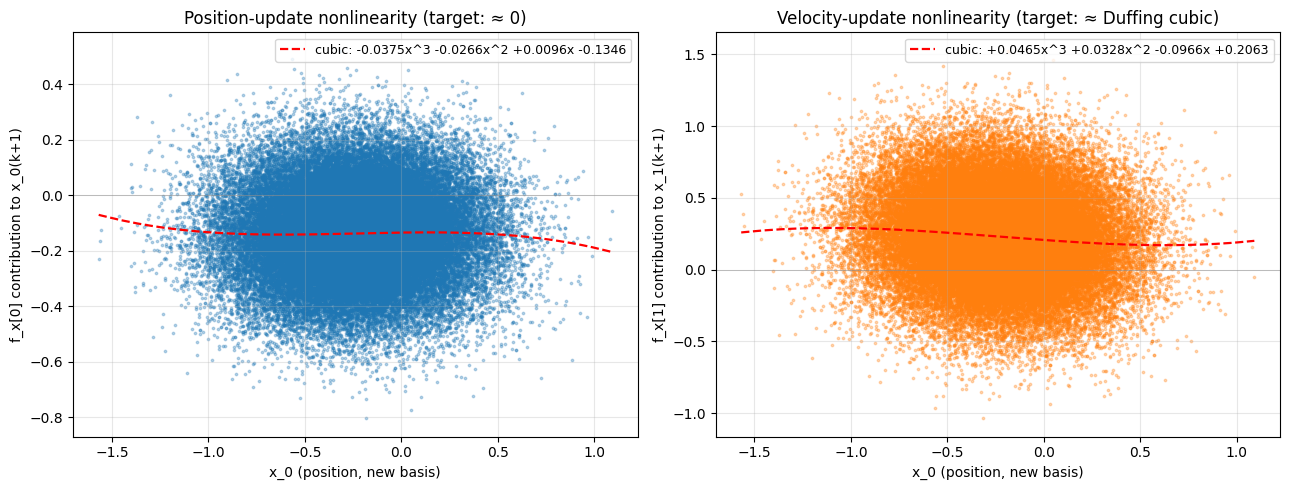

In [22]:
order = torch.argsort(x_traj[:, 0]).cpu().numpy()
x0  = x_traj[order, 0].cpu().numpy()
fx0 = f_x[order,    0].cpu().detach().numpy()
fx1 = f_x[order,    1].cpu().detach().numpy()

c0, fit0 = fit_cubic(x0, fx0)
c1, fit1 = fit_cubic(x0, fx1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x0, fx0, s=3, alpha=0.3)
axes[0].plot(x0, fit0, 'r--', lw=1.6,
             label=f'cubic: {c0[0]:+.4f}x^3 {c0[1]:+.4f}x^2 {c0[2]:+.4f}x {c0[3]:+.4f}')
axes[0].axhline(0, color='gray', lw=0.5, alpha=0.6)
axes[0].set(xlabel='x_0 (position, new basis)',
            ylabel='f_x[0] contribution to x_0(k+1)',
            title='Position-update nonlinearity (target: ≈ 0)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].scatter(x0, fx1, s=3, alpha=0.3, color='C1')
axes[1].plot(x0, fit1, 'r--', lw=1.6,
             label=f'cubic: {c1[0]:+.4f}x^3 {c1[1]:+.4f}x^2 {c1[2]:+.4f}x {c1[3]:+.4f}')
axes[1].axhline(0, color='gray', lw=0.5, alpha=0.6)
axes[1].set(xlabel='x_0 (position, new basis)',
            ylabel='f_x[1] contribution to x_1(k+1)',
            title='Velocity-update nonlinearity (target: ≈ Duffing cubic)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

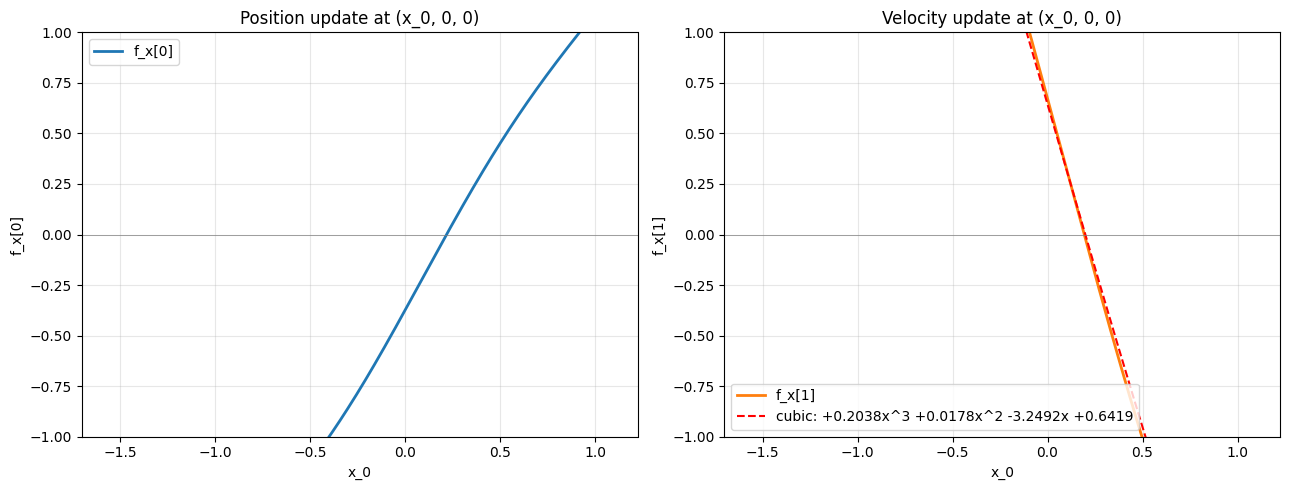


Isolated cubic coefficient in velocity update: +0.203837  ↔  −α·Δt/m  (normalised units)
Quadratic coefficient: +0.017752   (should be ~0 — pure cubic)
Linear coefficient:    -3.249249   (this is in addition to A_x[1,0] which is the linear stiffness)


In [23]:
T  = torch.tensor(T_np, dtype=torch.float32, device=device)
Tinv = torch.linalg.inv(T)

x0_grid = torch.linspace(x_traj[:, 0].min(), x_traj[:, 0].max(), 400, device=device).reshape(-1, 1)
x_grid  = torch.cat([x0_grid, torch.zeros_like(x0_grid)], dim=1)
u_zero  = torch.zeros_like(x0_grid)

with torch.no_grad():
    z_grid = x_grid @ T.T                                  # back to learned basis
    f_z_g  = model.state_kan_model(state=z_grid, u=u_zero) # KAN expects original basis
    f_x_g  = f_z_g @ Tinv.T

x0g  = x0_grid.cpu().numpy().squeeze()
fx0g = f_x_g[:, 0].cpu().numpy()
fx1g = f_x_g[:, 1].cpu().numpy()

c1g, fit1g = fit_cubic(x0g, fx1g)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(x0g, fx0g, lw=2, color='C0', label='f_x[0]'); ax[0].axhline(0, color='gray', lw=0.5)
ax[0].set(title='Position update at (x_0, 0, 0)', xlabel='x_0', ylabel='f_x[0]')
ax[0].grid(alpha=0.3); ax[0].legend()
ax[0].set_ylim(-1,1)

ax[1].plot(x0g, fx1g, lw=2, color='C1', label='f_x[1]')
ax[1].plot(x0g, fit1g, 'r--', lw=1.5,
           label=f'cubic: {c1g[0]:+.4f}x^3 {c1g[1]:+.4f}x^2 {c1g[2]:+.4f}x {c1g[3]:+.4f}')
ax[1].axhline(0, color='gray', lw=0.5)
ax[1].set(title='Velocity update at (x_0, 0, 0)', xlabel='x_0', ylabel='f_x[1]')
ax[1].grid(alpha=0.3); ax[1].legend()
ax[1].set_ylim(-1,1)
plt.tight_layout(); plt.show()

print(f"\nIsolated cubic coefficient in velocity update: {c1g[0]:+.6f}  ↔  −α·Δt/m  (normalised units)")
print(f"Quadratic coefficient: {c1g[1]:+.6f}   (should be ~0 — pure cubic)")
print(f"Linear coefficient:    {c1g[2]:+.6f}   (this is in addition to A_x[1,0] which is the linear stiffness)")

=== State-to-state slices in canonical basis (others held at 0) ===

A_x matrix:
tensor([[ 1.0000,  1.0000],
        [-0.1090,  0.6054]])


C:\Users\Maarten\AppData\Local\Temp\ipykernel_20880\1809315680.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  A_x_t  = torch.tensor(A_x, dtype=torch.float32, device=device)
C:\Users\Maarten\AppData\Local\Temp\ipykernel_20880\1809315680.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  B_x_t  = torch.tensor(B_x, dtype=torch.float32, device=device)


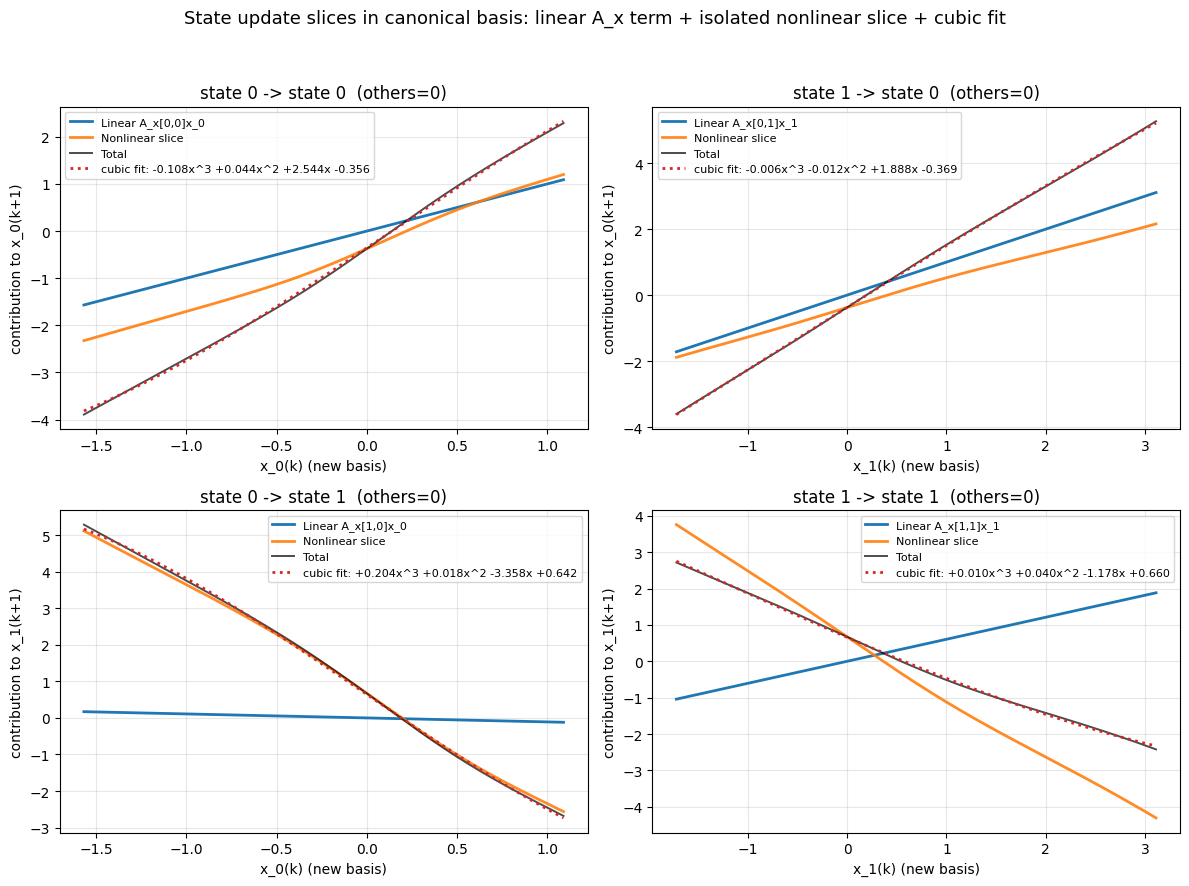


=== Input-to-state slices in canonical basis (x=0) ===

B_x matrix:
tensor([ 0.2092, -0.0085])


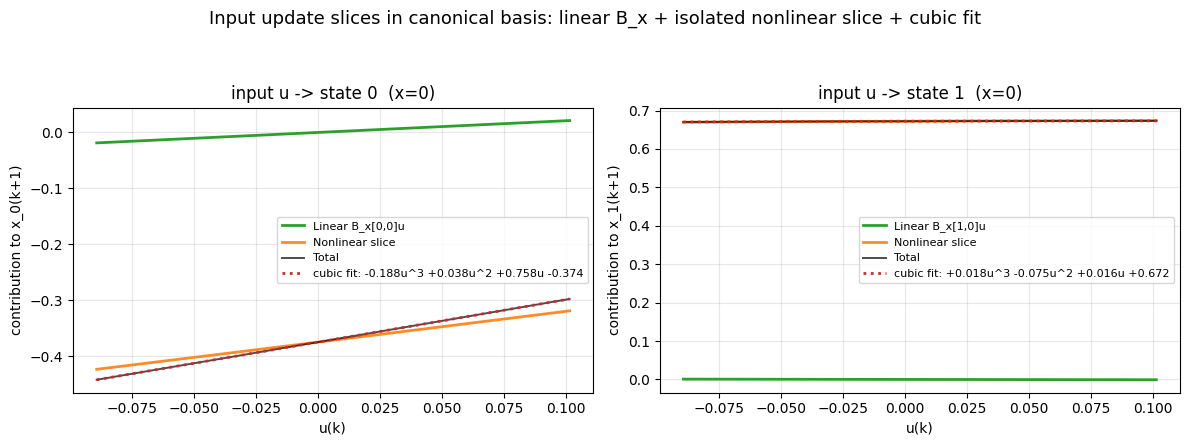


Per-slice RMS magnitudes (state-to-state, new basis, others=0):
  i=0 -> j=0: linear_rms=0.80581, nonlinear_rms=1.25232, nonlin/lin=1.554
  i=0 -> j=1: linear_rms=0.08786, nonlinear_rms=2.67559, nonlin/lin=30.452
  i=1 -> j=0: linear_rms=1.56081, nonlinear_rms=1.19552, nonlin/lin=0.766
  i=1 -> j=1: linear_rms=0.94498, nonlinear_rms=2.39008, nonlin/lin=2.529

Per-slice RMS magnitudes (input-to-state, new basis, x=0):
  u -> j=0: linear_rms=0.01161, nonlinear_rms=0.37226, nonlin/lin=32.052
  u -> j=1: linear_rms=0.00047, nonlinear_rms=0.67218, nonlin/lin=1427.774


In [24]:
import torch
import matplotlib.pyplot as plt

# Assumes T_np, A_x, B_x, x_traj, u_traj already exist from the earlier cells
T_t    = torch.tensor(T_np, dtype=torch.float32, device=device)
Tinv_t = torch.linalg.inv(T_t)
A_x_t  = torch.tensor(A_x, dtype=torch.float32, device=device)
B_x_t  = torch.tensor(B_x, dtype=torch.float32, device=device)

state_dim = model.state_dim
input_dim = u_traj.shape[1]
n_grid    = 400

# Per-axis ranges from the trajectory in the new basis
x_ranges = [(x_traj[:, i].min().item(), x_traj[:, i].max().item()) for i in range(state_dim)]
u_range  = (u_traj[:, 0].min().item(), u_traj[:, 0].max().item())

def eval_f_x_slice(varying_idx, varying_vals, is_input):
    """Evaluate f_x[j] when only one input (state index or input) varies, others=0."""
    n = varying_vals.shape[0]
    x_grid = torch.zeros(n, state_dim, device=device)
    u_grid = torch.zeros(n, input_dim, device=device)
    if is_input:
        u_grid[:, varying_idx] = varying_vals
    else:
        x_grid[:, varying_idx] = varying_vals
    with torch.no_grad():
        z_grid = x_grid @ T_t.T                                 # x -> z
        f_z    = model.state_kan_model(state=z_grid, u=u_grid)  # KAN in learned basis
        f_x    = f_z @ Tinv_t.T                                 # back to new basis
    return f_x

# ============ State-to-state slices ============
print('=== State-to-state slices in canonical basis (others held at 0) ===')
print(f'\nA_x matrix:\n{A_x_t}')

fig, axes = plt.subplots(state_dim, state_dim, figsize=(12, 9))
if state_dim == 1:
    axes = [[axes]]

for i in range(state_dim):
    xi_grid = torch.linspace(x_ranges[i][0], x_ranges[i][1], n_grid, device=device)
    f_x_slice = eval_f_x_slice(i, xi_grid, is_input=False)

    for j in range(state_dim):
        ax = axes[j][i]

        phi_ij      = f_x_slice[:, j]
        lin_ij      = A_x_t[j, i] * xi_grid
        edge_sum_ij = lin_ij + phi_ij

        X_cubic = torch.stack([xi_grid**3, xi_grid**2, xi_grid, torch.ones_like(xi_grid)], dim=1)
        coef = torch.linalg.lstsq(X_cubic, edge_sum_ij.unsqueeze(-1)).solution.squeeze()
        a3, a2, a1, a0 = [c.item() for c in coef]
        edge_fit  = coef[0]*xi_grid**3 + coef[1]*xi_grid**2 + coef[2]*xi_grid + coef[3]
        fit_label = f'cubic fit: {a3:+.3f}x^3 {a2:+.3f}x^2 {a1:+.3f}x {a0:+.3f}'

        xg = xi_grid.cpu()
        ax.plot(xg, lin_ij.cpu(),      lw=2.0, color='C0', label=f'Linear A_x[{j},{i}]x_{i}')
        ax.plot(xg, phi_ij.cpu(),      lw=2.0, color='C1', alpha=0.9, label='Nonlinear slice')
        ax.plot(xg, edge_sum_ij.cpu(), '-',  lw=1.4, color='black', alpha=0.7, label='Total')
        ax.plot(xg, edge_fit.cpu(),    ':',  lw=2.0, color='C3', label=fit_label)

        ax.set_title(f'state {i} -> state {j}  (others=0)')
        ax.set_xlabel(f'x_{i}(k) (new basis)')
        ax.set_ylabel(f'contribution to x_{j}(k+1)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)

fig.suptitle('State update slices in canonical basis: linear A_x term + isolated nonlinear slice + cubic fit', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ============ Input-to-state slices ============
print('\n=== Input-to-state slices in canonical basis (x=0) ===')
print(f'\nB_x matrix:\n{B_x_t.squeeze()}')

fig_u, axes_u = plt.subplots(1, state_dim, figsize=(12, 4.5))
if state_dim == 1:
    axes_u = [axes_u]

u_grid_vals = torch.linspace(u_range[0], u_range[1], n_grid, device=device)
f_x_u_slice = eval_f_x_slice(0, u_grid_vals, is_input=True)

for j in range(state_dim):
    axu = axes_u[j]

    phi_uj      = f_x_u_slice[:, j]
    lin_uj      = B_x_t[j, 0] * u_grid_vals
    edge_sum_uj = lin_uj + phi_uj

    U_cubic = torch.stack([u_grid_vals**3, u_grid_vals**2, u_grid_vals, torch.ones_like(u_grid_vals)], dim=1)
    coef_u = torch.linalg.lstsq(U_cubic, edge_sum_uj.unsqueeze(-1)).solution.squeeze()
    b3, b2, b1, b0 = [c.item() for c in coef_u]
    edge_fit_u  = coef_u[0]*u_grid_vals**3 + coef_u[1]*u_grid_vals**2 + coef_u[2]*u_grid_vals + coef_u[3]
    fit_u_label = f'cubic fit: {b3:+.3f}u^3 {b2:+.3f}u^2 {b1:+.3f}u {b0:+.3f}'

    ug = u_grid_vals.cpu()
    axu.plot(ug, lin_uj.cpu(),      lw=2.0, color='C2', label=f'Linear B_x[{j},0]u')
    axu.plot(ug, phi_uj.cpu(),      lw=2.0, color='C1', alpha=0.9, label='Nonlinear slice')
    axu.plot(ug, edge_sum_uj.cpu(), '-',  lw=1.4, color='black', alpha=0.7, label='Total')
    axu.plot(ug, edge_fit_u.cpu(),  ':',  lw=2.0, color='C3', label=fit_u_label)

    axu.set_title(f'input u -> state {j}  (x=0)')
    axu.set_xlabel('u(k)')
    axu.set_ylabel(f'contribution to x_{j}(k+1)')
    axu.grid(True, alpha=0.3)
    axu.legend(loc='best', fontsize=8)

fig_u.suptitle('Input update slices in canonical basis: linear B_x + isolated nonlinear slice + cubic fit', fontsize=13)
fig_u.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# ============ RMS diagnostics ============
print('\nPer-slice RMS magnitudes (state-to-state, new basis, others=0):')
for i in range(state_dim):
    xi_grid = torch.linspace(x_ranges[i][0], x_ranges[i][1], n_grid, device=device)
    f_x_slice = eval_f_x_slice(i, xi_grid, is_input=False)
    for j in range(state_dim):
        lin_rms = torch.sqrt(torch.mean((A_x_t[j, i] * xi_grid)**2)).item()
        non_rms = torch.sqrt(torch.mean(f_x_slice[:, j]**2)).item()
        print(f'  i={i} -> j={j}: linear_rms={lin_rms:.5f}, nonlinear_rms={non_rms:.5f}, nonlin/lin={non_rms/(lin_rms+1e-12):.3f}')

print('\nPer-slice RMS magnitudes (input-to-state, new basis, x=0):')
f_x_u_slice = eval_f_x_slice(0, u_grid_vals, is_input=True)
for j in range(state_dim):
    lin_rms = torch.sqrt(torch.mean((B_x_t[j, 0] * u_grid_vals)**2)).item()
    non_rms = torch.sqrt(torch.mean(f_x_u_slice[:, j]**2)).item()
    print(f'  u -> j={j}: linear_rms={lin_rms:.5f}, nonlinear_rms={non_rms:.5f}, nonlin/lin={non_rms/(lin_rms+1e-12):.3f}')